In [1]:
from neuron import h, gui
h.load_file("nrngui.hoc")
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import plotly
import plotly.express as px 
import numpy as np
import random
import math
import pickle
import os

In [2]:
!nrnivmodl

/Users/yingchieh/anaconda3/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/usr/bin/xcrun
/Users/yingchieh/Documents/202508_CA1PC_minimal
Mod files: "./caR.mod" "./cacumm.mod" "./cad.mod" "./cagk.mod" "./calH.mod" "./dists.mod" "./eff.mod" "./exc.mod" "./h.mod" "./ican.mod" "./icannov.mod" "./id.mod" "./inh.mod" "./kad.mod" "./kap.mod" "./kca.mod" "./kdr.mod" "./na3.mod" "./nmdaSyn.mod" "./pr.mod" "./pr_fix.mod" "./pr_fix_ramp.mod" "./pr_test.mod" "./sl.mod" "./syns.mod" "./vecevent.mod" "./vmax.mod" "./vmin.mod"

 -> Compiling mod_func.cpp
 => LINKING shared library ./libnrnmech.dylib
Successfully created arm64/special


In [3]:
# LOAD MORPHOLOGY

h("cellId = 1") # choose to cell to simulate; 1 or 2.
h.load_file("loadMorph.hoc")
h.load_file("resetNSeg.hoc")

#  ADJUST MORPHOLOGICAL AND ANNOTATION.
# 1: PROOFREAD.
# 2: CREATE SECTION LISTS THAT ASSIGN SECTIONS TO VARIOUS GROSS MORPHOLOGICAL
#    COMPARTMENTS (e.g., primary dendrite, tuft, basal) 
# 3:  ADJUST HOW NEURON RECOGNIZES VARIOUS SECTIONS

h.load_file("proofreadMorph.hoc")
h.load_file("idMorph.hoc")
h.load_file("processMorph.hoc")

# ONE-OFF SIMULATION: GET LENGTHS AND SURFACE AREAS OF DIFFERNET DOMAINS FOR BLOSS.  SEE EMAIL 07131
h.load_file("morphSummary.hoc")

The number of effective branches is 120 
	1 
tuftTermSa=2091.3942 
tufIntSa=880.34153 
oblTermSa=3813.0366 
oblIntSa=489.70324 
truckSa=1588.2207 
basPrimSa=203.36696 
basIntSa=906.95605 
basTermSa=2946.9947 
tuftTermL=1255.9764 
tuftIntL=298.56213 
oblTermL=1954.9848 
oblIntL=206.64296 
trunkL=275.91333 
basPrimL=39.149127 
basIntL=395.55933 
basTermL=1510.9204 


1.0

In [4]:
# IMPLEMENT INTRINSIC CHANNELS.
h.load_file("addChannels_per20250810.hoc")

1.0

In [5]:
# ADJUST NUMERICAL ASPECTS OF SIMULATION AND DISPLAY.
# THE FLAG doMovie ALLOWS GRAPHS TO BE RECORDED, IF DESIRED.
# THIS TAKES A FIXED TIME STEP AND DISTILLS GRAPHS FOR A WINDOW OF TIME.	
h.load_file("initializationAndRun.hoc")
h.load_file("displayPanels.hoc")

h("""
	doMovie=0
	if(doMovie){
		load_file("step.hoc")
	}
""")

	1 
	0 


1

In [6]:
# PLACE ALL INHIBITORY SYNAPSES (ie, all VGAT+ SYNAPSES) AND THEN ASSIGN THEM
# AS OTHER GENOTYPES (SST, PV) AS DETERMINED BY ARRAY TOMOGRAPHY DISTRIBUTIONS. 
h.load_file("addVgatInhibition.hoc")
h.load_file("synHelperScripts.hoc") # scripts retrieving synapse information
h.load_file("flagVgatInhibition.hoc")
h.load_file("inhibitionBiophysics.hoc") # assign vgat properties
h.load_file("activateInhibition.hoc") # script toggling active inhibition

#    h.load_file("checkConsistency.hoc") # deprecated; replaced by modelExpCheck below

h("seedGenotypes()") # add in inhibition
h.load_file("viewInhibition.hoc")

The total number of VGAT+ synapses in tuft is: 280 
The total number of VGAT+ synapses in obliques is: 114 
The total number of VGAT+ synapses in main apical is: 36 
The total number of VGAT+ synapses in soma is: 0 
The total number of VGAT+ synapses in basals is: 166 
The total number of VGAT+ synapses is: 596 
The total number of SST synapses in tuft is 164 
The total number of NPY synapses in obliques is 68 
The total number of NPY synapses in trunk is 30 
The total number of NPY synapses at soma is 0 
The total number of NPY synapses in basal is 86 
The total number of PV synapses in obliques is 15 
The total number of PV synapses at soma is 20 
The total number of PV synapses in basal is 16 
	1 
	1 
	1 
	1 
	1 
	1 


1.0

In [7]:
# PLACE ALL EXCITATORY SYNAPSES.

h.load_file("addExcitation.hoc")
h.load_file("activateExcitation.hoc") # script toggling active excitation
h.load_file("viewExcitation.hoc")

Number of excitatory connections is: 9510 
	1 


1.0

In [8]:
# DO A CHECK FOR CONSISTENTCY IN SYNAPTIC DISTRIBUTIONS BETWEEN MODEL AND EXPERIMENT. 
h("""
strdef genotypeToUse,domainToSurvey
{

	doCheck=0
	if(doCheck){
		genotypeToUse = "vgat" //  TYPE OF SYNAPSE, ONE OF"exc","vgat","sst","npy"
		domainToSurvey = "tuft" // DOMAIN TO CONSIDER, ONE OF "basal","prim","obl","tuft"
		partitionsToUse = 3 // NUMBER OF PARTITIONS.  AT DATA WAS EITHER = 1 OR = 3.
		
		load_file("modelExpCheck.hoc")
		modelExpCheck(genotypeToUse,domainToSurvey,partitionsToUse)
	}
}
""")

1

In [9]:
### Populate the neuron with Ca channel
### Swapped to other hoc files for pharmacological simulation
h.xopen("CalH_oblique_dend_test20250701.hoc")

	0 
	0 


1.0

In [10]:
h.initChannels()

0.0

In [11]:
h.load_file("initializationAndRun.hoc")

1.0

In [12]:
# Classification of the dendrites
# The all apical dendrites are [ijk for ijk in range(0,6795)] or np.arange(6795)
all_apical = []
left_apical = []
left_tuft = []
right_apical = []
right_tuft = []

subtree_to_test = []

for aa in h.Cell[0].dend[11].subtree():
    all_apical.append(str(aa))
for ll in h.Cell[0].dend[78].subtree():
    left_apical.append(str(ll))
for llt in h.Cell[0].dend[87].subtree():
    left_tuft.append(str(llt))
for rr in h.Cell[0].dend[151].subtree():
    right_apical.append(str(rr))
for rrt in h.Cell[0].dend[162].subtree():
    right_tuft.append(str(rrt))
for rrt in h.Cell[0].dend[163].subtree():
    right_tuft.append(str(rrt))
for stt in h.Cell[0].dend[87].subtree():  # Change the number here to test the subtree of interest
    subtree_to_test.append(str(stt))

all_tuft = left_tuft+right_tuft
apicalSynList = []
scSynList = []
left_and_common_scSynList = []
right_and_common_scSynList = []
ppSynList = []
left_ppSynList = []
right_ppSynList = []
stt_SynList = []

for syn in range(9510):
    syn_Location = str(h.synAmpa[syn].get_segment()).split("(")[0]
    if syn_Location in all_apical:
        apicalSynList.append(syn)
    if syn_Location in all_apical and syn_Location not in all_tuft:
        scSynList.append(syn)
        if syn_Location not in right_apical:
            left_and_common_scSynList.append(syn)
        if syn_Location not in left_apical:
            right_and_common_scSynList.append(syn)
    elif syn_Location in all_tuft:
        ppSynList.append(syn)
        if syn_Location in left_tuft:
            left_ppSynList.append(syn)
        if syn_Location in right_tuft:
            right_ppSynList.append(syn)
    if syn_Location in subtree_to_test:
        stt_SynList.append(syn)

print(right_ppSynList)

[325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524,

In [13]:
# (for Han-Ying's part simulation) Crudely classify the ca3 synapses into:
sc_1SynList = [] # the more proximal subdomain # paired to theta in Han-Ying's
sc_2SynList = [] # the more distal subdomain # paired to ramp in Han-Ying's
for ca3syn in scSynList:
    synSeg = str(h.synAmpa[ca3syn].get_segment()).split("]")[1]
    synSeg = synSeg.replace(".dend[","")
    synSeg = int(synSeg)
    syndist = h.distance(h.Cell[0].dend[synSeg](0.1))
    if syndist < 115: # an arbitrary cut-off; may require refinement later
        sc_1SynList.append(ca3syn)
    else:
        sc_2SynList.append(ca3syn)

In [14]:
### Load files for release probability (short-term plasticity)
### Prfix is for pharmacological testing of constant release probability

h.load_file("addPr.hoc")
h.load_file("addPrtest.hoc")
h.load_file("addPrfix.hoc")
h.load_file("addPrfix_ramp.hoc")

Number of Pr mechanisms is: 9510 
Number of Pr mechanisms is: 9510 
Number of Pr mechanisms is: 9510 
Number of Pr mechanisms is: 9510 


1.0

In [15]:
uprampprotocol = [500.    , 592.5674,  685.1274,  747.5974,  810.064,   859.704,
                    909.344, 951.598,  993.852,  1031.196,  1068.539,  1102.33,
                    1136.12,   1167.192, 1198.264,  1227.172,  1256.08,   1283.214,
                    1310.348,  1335.995,  1361.642, 1386.019,  1410.396,  1433.673,  
                    1456.949,  1479.26,   1501.57,   1523.025, 1544.48,   1565.17,
                    1585.86,   1605.86,   1625.86
]
downrampprotocol = [500.0, 520.0, 540.0, 560.69, 581.38, 602.835, 
                   624.29, 646.6, 668.911, 692.187, 715.464, 739.841,
                    764.218, 789.865, 815.512, 842.646, 869.78, 898.688,
                    927.596, 958.668, 989.74, 1023.53, 1057.321, 1094.664,
                    1132.008, 1174.262, 1216.516, 1266.156, 1315.796, 1378.2626,
                    1440.7326, 1533.2926, 1625.86
]
# uprampprotocol = np.array(uprampprotocol)
# uprampprotocol = uprampprotocol - 130
# uprampprotocol = list(uprampprotocol)

In [16]:
# Synaptic stimulation for modeling theta/ramp

nc_groups = [h.ncAmpa, h.ncNmda, h.ncVgatAt]
for nc_group in nc_groups:
    for nc in nc_group:
        if nc is not None:
            nc.active(False)

ca3_theta_syn = 45 
ca3_ramp_syn = 45 
ec_theta_syn = 27  

random.seed(1122)
sc_dom1_stim = random.sample(sc_1SynList,ca3_theta_syn)
sc_dom2_stim = random.sample(sc_2SynList,ca3_ramp_syn)
pp_dom_stim = random.sample(ppSynList,ec_theta_syn)
thetapath = sc_dom1_stim + pp_dom_stim
jointpath = sc_dom1_stim + sc_dom2_stim + pp_dom_stim

# ### For clustered cases 
# # sc_dom1_stim = [1032+20*isc1 for isc1 in range(9)] #dend[143]
# # sc_dom2_stim = [2820+20*isc for isc in range(9)] #dend[133]
# # pp_dom_stim = [243+4*ip for ip in range(9)] #dend[107]
# # jointpath = sc_dom1_stim + sc_dom2_stim + pp_dom_stim

thetaprotocol = thetaprotocol = [200*(i)+10*(j) for i in range(5) for j in range(5)]
thetaprotocol = np.array(thetaprotocol)
nothetaprotocol = [380+10*l for l in range(25)]
nothetaprotocol = np.array(nothetaprotocol)

rampprotocol = np.array([
    0, 0.0925674, 0.155034, 0.204674, 0.246928,
    0.284272, 0.318062, 0.349134, 0.378042, 0.405176,
    0.430823, 0.4552, 0.478477, 0.500787, 0.522242,
    0.542932, 0.562932, 0.582932, 0.603622, 0.625077,
    0.647388, 0.670664, 0.695041, 0.720688, 0.747822,
    0.77673, 0.807802, 0.841593, 0.878936, 0.92119,
    0.97083, 1.0333, 1.12586
])
rampprotocol = rampprotocol * 1000 # convert second to ms
norampprotocol = [155+((1145-305)/32)*k for k in range(33)] # fixed frequency with start and end alighned to those of theta 
# norampprotocol = [((1275.86-150)/32)*k for k in range(33)] # fixed frequency with start and end alighned to those of ramp
######### 33 is the total #stimulation for ramp protocol, so no need to change 
norampprotocol = np.array(norampprotocol)

# Delay for 500ms to wait for initialization of membrane potential
thetaprotocol = thetaprotocol +155 + 500
nothetaprotocol = nothetaprotocol + 500
rampprotocol = rampprotocol+500
norampprotocol = norampprotocol+500

jointprotocol = np.concatenate((thetaprotocol,rampprotocol,thetaprotocol)) # manually switch here for different cases
# jointprotocol = np.array(jointprotocol)

### Convert each protocol back to list to let it be taken by h.Vector()
rampprotocol = list(rampprotocol)
norampprotocol = list(norampprotocol)
thetaprotocol = list(thetaprotocol)
nothetaprotocol = list(nothetaprotocol)

use_ramp = True
use_theta = True
ramp_stim_series = h.VecStim()
theta_stim_series = h.VecStim()
if use_ramp:
    ramp_stim_series.play(h.Vector(rampprotocol))
if not use_ramp:
    ramp_stim_series.play(h.Vector(norampprotocol))
if use_theta:    
    theta_stim_series.play(h.Vector(thetaprotocol))
if not use_theta:
    theta_stim_series.play(h.Vector(nothetaprotocol))

nc_list = []
synList = []

randObjlist_ramp = [h.Random() for _ in range(ca3_ramp_syn)]
randObjdict_ramp = {f"randObj_{ir}": randObj for ir, randObj in enumerate(randObjlist_ramp)}
randObjlist_theta = [h.Random() for _ in range(ca3_theta_syn+ec_theta_syn)]
randObjdict_theta = {f"randObj_{ir}": randObj for ir, randObj in enumerate(randObjlist_theta)}

use_constant_release_prob = False

if not use_constant_release_prob:
    for synTerm in range(ca3_ramp_syn):
        synNumber = sc_dom2_stim[synTerm]

        randObjdict_ramp[f"randObj_{synTerm}"].MCellRan4(1,217420001+synTerm)
        randObjdict_ramp[f"randObj_{synTerm}"].uniform(0,1)
        h.PrExc[synNumber].setRandObjRef(randObjdict_ramp[f"randObj_{synTerm}"])

        nc_stimtoPr = h.NetCon(ramp_stim_series,h.PrExc[synNumber])
        nc_list.append(nc_stimtoPr)

        nc_PrtoAmpa = h.NetCon(h.PrExc[synNumber],h.synAmpa[synNumber])
        nc_PrtoAmpa.weight[0] = 0.00018
        h.synAmpa[synNumber].isOn = 1
        nc_list.append(nc_PrtoAmpa)

        nc_PrtoNmda = h.NetCon(h.PrExc[synNumber], h.synNmda[synNumber])
        nc_PrtoNmda.weight[0] = 0.00036
        h.synNmda[synNumber].isOn = 1
        nc_list.append(nc_PrtoNmda)

        synList.append(synNumber)

    for synTerm2 in range(ca3_theta_syn+ec_theta_syn):
        synNumber = thetapath[synTerm2]

        randObjdict_theta[f"randObj_{synTerm2}"].MCellRan4(1,217421000+synTerm2)
        randObjdict_theta[f"randObj_{synTerm2}"].uniform(0,1)
        h.PrExc_new[synNumber].setRandObjRef(randObjdict_theta[f"randObj_{synTerm2}"])

        nc_stimtoPr = h.NetCon(theta_stim_series,h.PrExc_new[synNumber])
        nc_list.append(nc_stimtoPr)

        nc_PrtoAmpa = h.NetCon(h.PrExc_new[synNumber],h.synAmpa[synNumber])
        nc_PrtoAmpa.weight[0] = 0.00018
        h.synAmpa[synNumber].isOn = 1
        nc_list.append(nc_PrtoAmpa)

        nc_PrtoNmda = h.NetCon(h.PrExc_new[synNumber], h.synNmda[synNumber])
        nc_PrtoNmda.weight[0] = 0.00036
        h.synNmda[synNumber].isOn = 1
        nc_list.append(nc_PrtoNmda)

        synList.append(synNumber)

else:
    for synTerm in range(ca3_ramp_syn):
        synNumber = sc_dom2_stim[synTerm]

        randObjdict_ramp[f"randObj_{synTerm}"].MCellRan4(1,217420001+synTerm)
        randObjdict_ramp[f"randObj_{synTerm}"].uniform(0,1)
        h.PrExc_fix_ramp[synNumber].setRandObjRef(randObjdict_ramp[f"randObj_{synTerm}"])

        nc_stimtoPr = h.NetCon(ramp_stim_series,h.PrExc_fix_ramp[synNumber])
        nc_list.append(nc_stimtoPr)

        nc_PrtoAmpa = h.NetCon(h.PrExc_fix_ramp[synNumber],h.synAmpa[synNumber])
        nc_PrtoAmpa.weight[0] = 0.00018
        h.synAmpa[synNumber].isOn = 1
        nc_list.append(nc_PrtoAmpa)

        nc_PrtoNmda = h.NetCon(h.PrExc_fix_ramp[synNumber], h.synNmda[synNumber])
        nc_PrtoNmda.weight[0] = 0.00036
        h.synNmda[synNumber].isOn = 1
        nc_list.append(nc_PrtoNmda)

        synList.append(synNumber)

    for synTerm2 in range(ca3_theta_syn+ec_theta_syn):
        synNumber = thetapath[synTerm2]

        randObjdict_theta[f"randObj_{synTerm2}"].MCellRan4(1,217421000+synTerm2)
        randObjdict_theta[f"randObj_{synTerm2}"].uniform(0,1)
        h.PrExc_fix[synNumber].setRandObjRef(randObjdict_theta[f"randObj_{synTerm2}"])

        nc_stimtoPr = h.NetCon(theta_stim_series,h.PrExc_fix[synNumber])
        nc_list.append(nc_stimtoPr)

        nc_PrtoAmpa = h.NetCon(h.PrExc_fix[synNumber],h.synAmpa[synNumber])
        nc_PrtoAmpa.weight[0] = 0.00018
        h.synAmpa[synNumber].isOn = 1
        nc_list.append(nc_PrtoAmpa)

        nc_PrtoNmda = h.NetCon(h.PrExc_fix[synNumber], h.synNmda[synNumber])
        nc_PrtoNmda.weight[0] = 0.00036
        h.synNmda[synNumber].isOn = 1
        nc_list.append(nc_PrtoNmda)

        synList.append(synNumber)

print(synList)
print(nc_list)

[6661, 5403, 5486, 3958, 3890, 3484, 4136, 3891, 3312, 4961, 6335, 4677, 4923, 5641, 4232, 5611, 6382, 5616, 2760, 4058, 2984, 3410, 3270, 2716, 5018, 5610, 5037, 5678, 4501, 5362, 4765, 6364, 4555, 4415, 3268, 3311, 4645, 4288, 2771, 5243, 5103, 5052, 5618, 5468, 5664, 2574, 3816, 729, 5808, 1656, 1974, 3796, 5735, 3682, 1149, 1422, 2391, 6100, 1325, 837, 987, 6499, 5785, 1549, 6534, 2090, 1451, 5989, 2461, 1369, 1254, 6532, 1364, 5819, 2360, 3147, 968, 2596, 5916, 1738, 1113, 635, 1048, 2503, 769, 1967, 6552, 1502, 1393, 3834, 18, 247, 65, 353, 369, 184, 249, 298, 293, 417, 103, 246, 95, 365, 559, 31, 313, 190, 54, 387, 236, 196, 467, 20, 21, 362, 509]
[NetCon[19616], NetCon[19617], NetCon[19618], NetCon[19619], NetCon[19620], NetCon[19621], NetCon[19622], NetCon[19623], NetCon[19624], NetCon[19625], NetCon[19626], NetCon[19627], NetCon[19628], NetCon[19629], NetCon[19630], NetCon[19631], NetCon[19632], NetCon[19633], NetCon[19634], NetCon[19635], NetCon[19636], NetCon[19637], NetCon

In [17]:
tstop = 1800

In [18]:
# Recording sites (near SR-SLM border)
dendLocation1 = 101
dendClampSec = 0.928571

h.xopen("Cur_record.hoc")

dendInd1VoltRecords = h.Vector().record(h.Cell[0].dend[dendLocation1](dendClampSec)._ref_v)
SomaRecords = h.Vector().record(h.Cell[0].dend[72](0.5)._ref_v)

t = h.Vector().record(h._ref_t)

	Vector[3829] 
	Vector[3830] 
	Vector[3835] 
	Vector[3836] 
	Vector[3837] 
	Vector[3838] 
	Vector[3839] 
	Vector[3832] 
	Vector[3831] 


In [19]:
# Record Ca current
h("""
objref LCacurdend, RCacurdend, icancurdend, NaCurdend, NMDAcurneardend, kapcurdend, kadcurdend, kdrcurdend, cagkcurdend, kcacurdend
  LCacurdend = new Vector()
  RCacurdend = new Vector()
  icancurdend = new Vector()
  NaCurdend = new Vector()
  NMDAcurneardend = new Vector()
  kapcurdend = new Vector()
  kadcurdend = new Vector()
  kdrcurdend = new Vector()
  cagkcurdend = new Vector()
  kcacurdend = new Vector()
  LCacurdend.record(&Cell[0].dend[101].ica_calH(0.928571))
  RCacurdend.record(&Cell[0].dend[101].ica_car(0.928571))
  icancurdend.record(&Cell[0].dend[101].itrpm4_ican(0.928571))
  NaCurdend.record(&Cell[0].dend[101].ina(0.928571))
  NMDAcurneardend.record(&synNmda[31].i)
  kapcurdend.record(&Cell[0].dend[101].ik_kap(0.928571))
  kadcurdend.record(&Cell[0].dend[101].ik_kad(0.928571))
  kdrcurdend.record(&Cell[0].dend[101].ik_kdr(0.928571))
  cagkcurdend.record(&Cell[0].dend[101].ik_cagk(0.928571))
  kcacurdend.record(&Cell[0].dend[101].ik_kca(0.928571))
""")
cai_cacumm_SLM = h.Vector().record(h.Cell[0].dend[101](0.928571)._ref_cai)
h("""
objref can_SLM, Po_SLM
    can_SLM = new Vector()
    Po_SLM = new Vector()
    can_SLM.record(&Cell[0].dend[101].can_ican(0.928571))
    Po_SLM.record(&Cell[0].dend[101].Po_ican(0.928571))
""")

	Vector[3855] 
	Vector[3856] 
	Vector[3857] 
	Vector[3858] 
	Vector[3859] 
	Vector[3860] 
	Vector[3861] 
	Vector[3862] 
	Vector[3863] 
	Vector[3864] 
	Vector[3866] 
	Vector[3867] 


1

In [ ]:
##### Plot the neuron morphology and stimulated synapses (color-coded for different pathways)
##### Can be very time-consuming to run, so defaultedly commented out except need to check sth or make ppt slides

# ps = h.PlotShape(False)

# # ps.variable("v")
# # ps.scale(-80, 0)

# fig = ps.plot(plotly, cmap=plt.cm.jet, line=dict(width=5))
# # fig = ps.plot(plotly, cmap=plt.cm.gray, line=dict(width=5), show_diam=True, diam_scale=2.5)

# # mark recording sites

# fig.mark(h.Cell[0].dend[101](0.928571), marker_color = "blue", marker_size = 2.5)
# # fig.mark(h.Cell[0].dend[72](0.5), marker_color = "blue", marker_size = 2.5)

# # for stim in synList:
# #     fig.mark(h.synAmpa[stim].get_segment(),marker_color = "red", marker_size = 2)
# for stim in sc_dom1_stim:
#     fig.mark(h.synAmpa[stim].get_segment(),marker_color = "darkolivegreen", marker_size = 1.8)
# for stim in sc_dom2_stim:
#     fig.mark(h.synAmpa[stim].get_segment(),marker_color = "orangered", marker_size = 1.8)
# for stim in pp_dom_stim:
#     fig.mark(h.synAmpa[stim].get_segment(),marker_color = "purple", marker_size = 1.8)

# camera = dict(
#     eye=dict(x=0., y=0., z=3.5),
#     up=dict(x=0., y=1., z=0.),
# )

# fig.update_layout(scene_camera=camera, showlegend=False, scene_aspectmode="data",
#     width=600, height=800)
# fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
# fig.show()

In [21]:
############ For plotting voltage
voltages_collect = []

for sec in h.allsec():
    for seg in sec.allseg():
        v_vec = h.Vector()
        v_vec.record(seg._ref_v)
        voltages_collect.append(v_vec)
        print(seg, v_vec)

Cell[0].dend[0](0) Vector[3868]
Cell[0].dend[0](0.0333333) Vector[3869]
Cell[0].dend[0](0.1) Vector[3870]
Cell[0].dend[0](0.166667) Vector[3871]
Cell[0].dend[0](0.233333) Vector[3872]
Cell[0].dend[0](0.3) Vector[3873]
Cell[0].dend[0](0.366667) Vector[3874]
Cell[0].dend[0](0.433333) Vector[3875]
Cell[0].dend[0](0.5) Vector[3876]
Cell[0].dend[0](0.566667) Vector[3877]
Cell[0].dend[0](0.633333) Vector[3878]
Cell[0].dend[0](0.7) Vector[3879]
Cell[0].dend[0](0.766667) Vector[3880]
Cell[0].dend[0](0.833333) Vector[3881]
Cell[0].dend[0](0.9) Vector[3882]
Cell[0].dend[0](0.966667) Vector[3883]
Cell[0].dend[0](1) Vector[3884]
Cell[0].dend[1](0) Vector[3885]
Cell[0].dend[1](0.5) Vector[3886]
Cell[0].dend[1](1) Vector[3887]
Cell[0].dend[2](0) Vector[3888]
Cell[0].dend[2](0.166667) Vector[3889]
Cell[0].dend[2](0.5) Vector[3890]
Cell[0].dend[2](0.833333) Vector[3891]
Cell[0].dend[2](1) Vector[3892]
Cell[0].dend[3](0) Vector[3893]
Cell[0].dend[3](0.5) Vector[3894]
Cell[0].dend[3](1) Vector[3895]
Cel

In [22]:
############ For plotting intracellular calcium concentration
cai_collect = []

for sec in h.allsec():
    for seg in sec.allseg():
        cai_vec = h.Vector()
        cai_vec.record(seg._ref_cai)
        cai_collect.append(cai_vec)
        print(seg, cai_vec)

Cell[0].dend[0](0) Vector[5524]
Cell[0].dend[0](0.0333333) Vector[5525]
Cell[0].dend[0](0.1) Vector[5526]
Cell[0].dend[0](0.166667) Vector[5527]
Cell[0].dend[0](0.233333) Vector[5528]
Cell[0].dend[0](0.3) Vector[5529]
Cell[0].dend[0](0.366667) Vector[5530]
Cell[0].dend[0](0.433333) Vector[5531]
Cell[0].dend[0](0.5) Vector[5532]
Cell[0].dend[0](0.566667) Vector[5533]
Cell[0].dend[0](0.633333) Vector[5534]
Cell[0].dend[0](0.7) Vector[5535]
Cell[0].dend[0](0.766667) Vector[5536]
Cell[0].dend[0](0.833333) Vector[5537]
Cell[0].dend[0](0.9) Vector[5538]
Cell[0].dend[0](0.966667) Vector[5539]
Cell[0].dend[0](1) Vector[5540]
Cell[0].dend[1](0) Vector[5541]
Cell[0].dend[1](0.5) Vector[5542]
Cell[0].dend[1](1) Vector[5543]
Cell[0].dend[2](0) Vector[5544]
Cell[0].dend[2](0.166667) Vector[5545]
Cell[0].dend[2](0.5) Vector[5546]
Cell[0].dend[2](0.833333) Vector[5547]
Cell[0].dend[2](1) Vector[5548]
Cell[0].dend[3](0) Vector[5549]
Cell[0].dend[3](0.5) Vector[5550]
Cell[0].dend[3](1) Vector[5551]
Cel

In [23]:
# Run simulations
h.finitialize(h.v_init)
h.continuerun(tstop)

init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0init_t:0

0.0

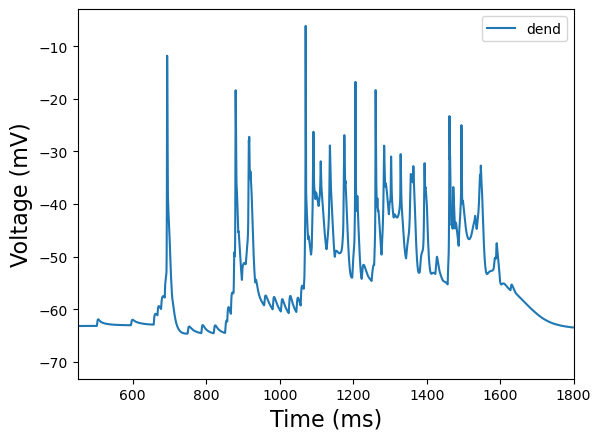

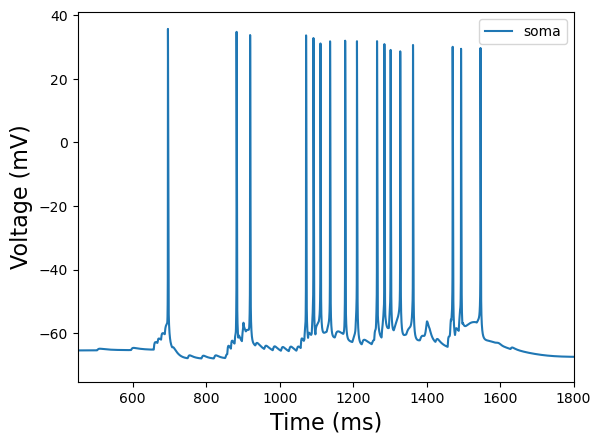

In [24]:
### Generate voltage trace plot with axis

plt.plot(t,dendInd1VoltRecords,label="dend")
plt.xlim(450,tstop)
plt.xlabel("Time (ms)",fontsize=16)
plt.ylabel("Voltage (mV)",fontsize=16)
plt.legend()
plt.show()

plt.plot(t,SomaRecords,label="soma")
plt.xlim(450,tstop)
plt.xlabel("Time (ms)",fontsize=16)
plt.ylabel("Voltage (mV)",fontsize=16)
plt.legend()
plt.show()

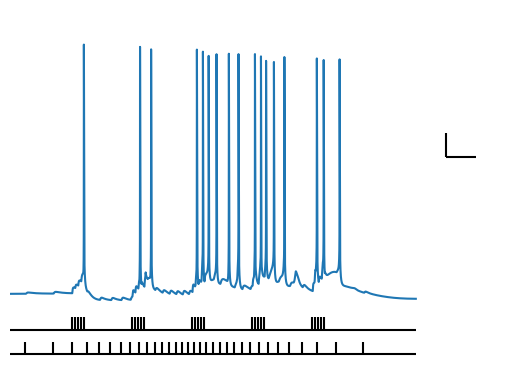

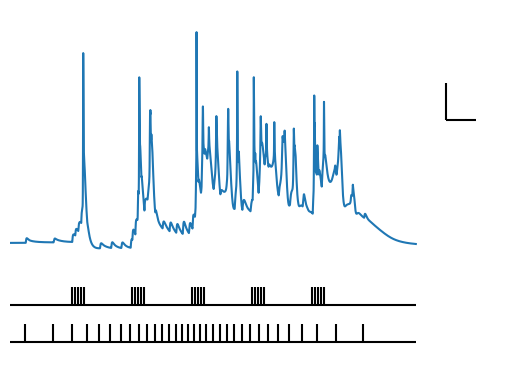

In [25]:
# For plotting theta/ramp results
plt.plot(t, SomaRecords)
plt.hlines(-80,100,1800,color="black")
if use_theta:
    for thetainput in thetaprotocol:
        plt.vlines(thetainput,-80,-75,color="black")
if not use_theta:
    for nothetainput in nothetaprotocol:
        plt.vlines(nothetainput,-80,-75,color="black")
plt.hlines(-90,100,1800, color="black")
if use_ramp:
    for rampinput in rampprotocol:
        plt.vlines(rampinput,-90,-85,color="black")
if not use_ramp:
    for norampinput in norampprotocol:
        plt.vlines(norampinput,-90,-85,color="black")
plt.vlines(1900,-10,0,color="black")
plt.hlines(-10,1900,2000,color="black")
plt.xlim(450,2100)
plt.ylim(-100,50)
plt.axis('off')
plt.show()

plt.plot(t, dendInd1VoltRecords)
plt.hlines(-80,100,1800,color="black")
if use_theta:
    for thetainput in thetaprotocol:
        plt.vlines(thetainput,-80,-75,color="black")
if not use_theta:
    for nothetainput in nothetaprotocol:
        plt.vlines(nothetainput,-80,-75,color="black")
plt.hlines(-90,100,1800, color="black")
if use_ramp:
    for rampinput in rampprotocol:
        plt.vlines(rampinput,-90,-85,color="black")
if not use_ramp:
    for norampinput in norampprotocol:
        plt.vlines(norampinput,-90,-85,color="black")
plt.vlines(1900,-30,-20,color="black")
plt.hlines(-30,1900,2000,color="black")
plt.xlim(450,2100)
plt.ylim(-100,0)
plt.axis('off')
plt.show()

In [26]:
Exportthisround = False
if Exportthisround:
    with open("new_downramp_trace_20250725",'wb') as f:   ### !!!!!!!! Remember to change the file name !!!!!!!! ###
        pickle.dump(dendInd1VoltRecords,f)

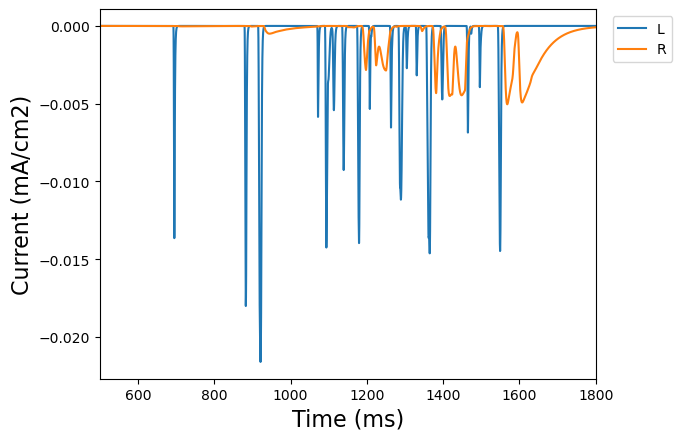

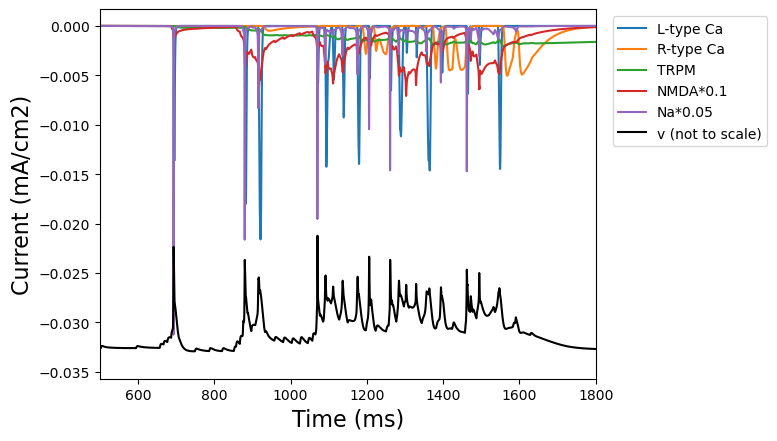

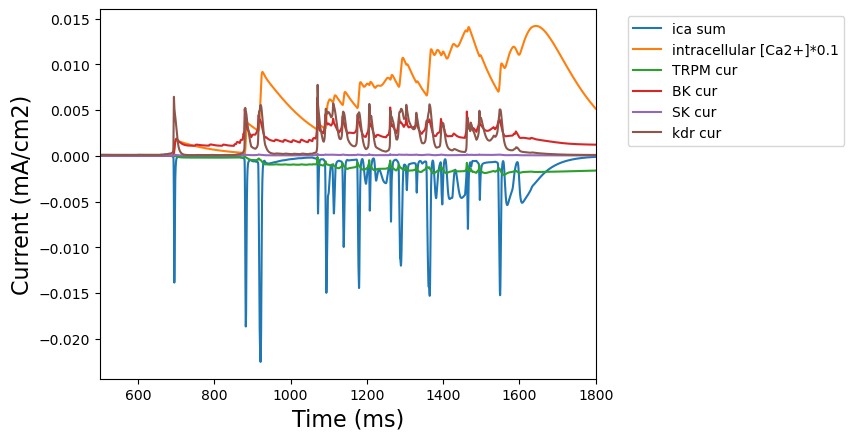

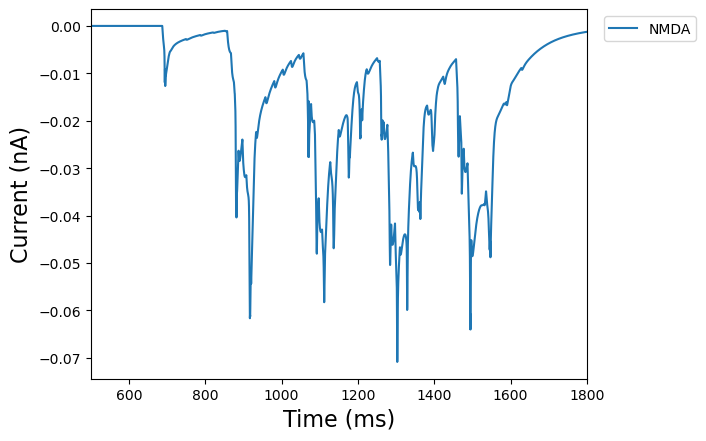

In [27]:
Lcur = h.LCacurdend
Rcur = h.RCacurdend
icanCur = h.icancurdend
NaCur = h.NaCurdend
cagkCur = h.cagkcurdend
kacCur = h.kcacurdend
NMDACur = h.NMDAcurneardend
kdrCur = h.kdrcurdend
kaCur = h.kapcurdend + h.kadcurdend
LRcursum = h.LCacurdend + h.RCacurdend
Cacursum = h.LCacurdend + h.RCacurdend + 0.1*h.NMDAcurneardend

surface_area_NMDAR = h.Cell[0].dend[101](0.214286).area()
NMDACur = (NMDACur/surface_area_NMDAR) * 1/((1e6/(1e4*1e4)))  ## convert nA/µm2 to mA/cm2 

plt.plot(t,Lcur,label="L")
plt.plot(t,Rcur,label="R")
# plt.plot(t,LRcursum,label="L+R sum",linestyle='--')
plt.xlabel("Time (ms)",fontsize=16)
plt.ylabel("Current (mA/cm2)",fontsize=16)
plt.xlim(500,tstop)
plt.legend(bbox_to_anchor=(1.02,1))
plt.show()

plt.plot(t,Lcur,label="L-type Ca")
plt.plot(t,Rcur,label="R-type Ca")
plt.plot(t,icanCur,label="TRPM")
plt.plot(t,NMDACur*0.1,label="NMDA*0.1")
plt.plot(t,NaCur*0.05,label="Na*0.05")
plt.xlabel("Time (ms)",fontsize=16)
plt.ylabel("Current (mA/cm2)",fontsize=16)
plt.plot(t,dendInd1VoltRecords*0.0002-0.02,label="v (not to scale)",color="black")
plt.legend(bbox_to_anchor=(1.02,1))
plt.xlim(500,1800)
plt.show()

plt.plot(t,Cacursum,label="ica sum")
plt.plot(t,cai_cacumm_SLM*0.1,label="intracellular [Ca2+]*0.1")
plt.plot(t,icanCur,label="TRPM cur")
plt.plot(t, cagkCur, label="BK cur")
plt.plot(t, kacCur, label="SK cur")
plt.plot(t, kdrCur, label="kdr cur")
# plt.plot(t,kaCur,label="ka cur")
# plt.plot(t,h.can_SLM,label="nanodomain [Ca2+]")
# plt.plot(t,h.Po_SLM,label="open prob. of ican\n (not to scale)")
# plt.plot(t,(dendInd1VoltRecords+100)*0.0005-0.06,label="v (not to scale)")
plt.xlabel("Time (ms)",fontsize=16)
plt.ylabel("Current (mA/cm2)",fontsize=16)
plt.xlim(500,tstop)
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

plt.plot(t,NMDACur,label="NMDA")
plt.xlabel("Time (ms)",fontsize=16)
plt.ylabel("Current (nA)",fontsize=16) # NMDA current
plt.xlim(500,tstop)
plt.legend(bbox_to_anchor=(1.02,1))
plt.show()